# Telco Customer Churn — Model Training

This notebook focuses on training machine learning models to predict customer churn using the cleaned Telco Customer Churn dataset.

The objective is to build reproducible training pipelines and compare different classification algorithms.

## Modeling Goals

The model training stage focuses on:

- Preparing features for machine learning models
- Building preprocessing pipelines
- Preventing data leakage
- Performing cross-validation
- Exploring hyperparameter tuning
- Comparing multiple classification models
- Creating reproducible training workflows

## Models Used

The following machine learning models are explored:

- **Logistic Regression**
- **Decision Tree Classifier**
- **Random Forest Classifier**
- **XGBoost Classifier**


## Import Section

In [57]:
import os

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from joblib import Memory, dump
from scipy.stats import loguniform, randint, uniform
from sklearn.compose import (
	ColumnTransformer,
	make_column_selector,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
	ConfusionMatrixDisplay,
	RocCurveDisplay,
	accuracy_score,
	classification_report,
	confusion_matrix,
	f1_score,
	precision_score,
	recall_score,
	roc_auc_score,
)
from sklearn.model_selection import (
	RandomizedSearchCV,
	RepeatedStratifiedKFold,
	cross_val_score,
	train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

## Load Processed Dataset

The dataset used in this notebook was previously cleaned and standardized during the data preparation stage.

In [58]:
telco_churn = pd.read_parquet('../data/processed/telco_churn_clean.parquet')

In [59]:
telco_churn.sample(5)

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
5317,Female,0,No,No,6,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,Yes,Bank transfer (automatic),49.650002,Yes
3280,Male,0,Yes,No,55,Yes,No,DSL,Yes,Yes,Yes,No,No,No,Two year,No,Electronic check,58.599998,No
2728,Female,0,No,No,25,No,No phone service,DSL,Yes,Yes,Yes,No,Yes,Yes,One year,No,Electronic check,61.049999,No
1301,Female,0,Yes,Yes,66,Yes,No,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Credit card (automatic),58.200001,No
3450,Male,1,Yes,No,70,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Electronic check,104.800003,No


## Reproducibility Configuration

A fixed random state is defined to ensure reproducible experiments across all training procedures.

In [60]:
RANDOM_STATE = 42

## Feature and Target Definition

The dataset is separated into:

- Features (X)
- Target variable (y)

Customer churn is used as the prediction target.

In [61]:
X = telco_churn.drop('Churn', axis=1)
y = telco_churn['Churn']

In [62]:
X.shape, y.shape

((7043, 18), (7043,))

## Train-Test Split

The dataset is divided into training and testing subsets.

Stratification is applied to preserve the original churn distribution.

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
	X,
	y,
	test_size=0.2,
	stratify=y,
	random_state=RANDOM_STATE,
)

In [64]:
X_train.shape, y_train.shape

((5634, 18), (5634,))

In [65]:
X_train.dtypes

Gender              category
SeniorCitizen          int64
Partner             category
Dependents          category
Tenure                 int16
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float32
dtype: object

In [66]:
y_train.dtypes

CategoricalDtype(categories=['No', 'Yes'], ordered=False, categories_dtype=str)

In [67]:
X_test.shape, y_test.shape

((1409, 18), (1409,))

## Feature Preprocessing

Different preprocessing strategies are applied depending on feature type:

- Numerical features are standardized using scaling transformations
- Categorical features are encoded using one-hot encoding

Separate preprocessing pipelines are combined using a ColumnTransformer to centralize transformations and ensure reproducible workflows.

In [68]:
num_pipe = Pipeline(
	steps=[
		('scl', StandardScaler()),
	]
)

In [69]:
display(num_pipe)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scl', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [70]:
cat_pipe = Pipeline(
	steps=[
		('enc', OneHotEncoder(handle_unknown='ignore')),
	]
)

In [71]:
display(cat_pipe)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('enc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies 

In [72]:
num_cols = make_column_selector(dtype_include=np.number)
cat_cols = make_column_selector(dtype_include='category')

In [73]:
prep = ColumnTransformer(
	transformers=[
		('num', num_pipe, num_cols),
		('cat', cat_pipe, cat_cols),
	],
)

In [74]:
display(prep)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Cross-Validation Strategy

Repeated Stratified K-Fold cross-validation is used to preserve class proportions across validation folds while improving robustness through multiple repetitions.

This strategy reduces variance in performance estimation and provides more stable evaluation results for imbalanced classification tasks.

In [75]:
RSKF_N_SPLITS = 5
RSKF_N_REPEATS = 5

In [76]:
rskf = RepeatedStratifiedKFold(
	n_splits=RSKF_N_SPLITS,
	n_repeats=RSKF_N_REPEATS,
	random_state=RANDOM_STATE,
)

## Helper Functions

Reusable utilities for model evaluation and artifact persistence.

Centralizing these routines eliminates repeated boilerplate across model sections and guarantees consistent evaluation logic for every classifier.

In [77]:
def compute_metrics(y_test, y_pred, y_proba, pos_label='Yes'):
	"""
	Compute all classification metrics for churn prediction.

	Returns
	-------
	dict
	    ROC-AUC, accuracy, precision, recall, and F1 on the test set.
	"""
	return {
		'test_roc_auc': roc_auc_score(y_test, y_proba),
		'test_accuracy': accuracy_score(y_test, y_pred),
		'test_precision': precision_score(
			y_test,
			y_pred,
			pos_label=pos_label,
		),
		'test_recall': recall_score(
			y_test,
			y_pred,
			pos_label=pos_label,
		),
		'test_f1': f1_score(
			y_test,
			y_pred,
			pos_label=pos_label,
		),
	}


def print_metrics(metrics):
	"""Print classification metrics in a formatted layout."""
	print(f'ROC-AUC  : {metrics["test_roc_auc"]:.4f}')
	print(f'Accuracy : {metrics["test_accuracy"]:.4f}')
	print(f'Precision: {metrics["test_precision"]:.4f}')
	print(f'Recall   : {metrics["test_recall"]:.4f}')
	print(f'F1-Score : {metrics["test_f1"]:.4f}')


def build_classification_report(y_test, y_pred):
	"""
	Return a tidy DataFrame classification report,
	excluding the accuracy row.
	"""
	report = classification_report(
		y_test,
		y_pred,
		output_dict=True,
	)

	return pd.DataFrame(report).transpose().iloc[:-1, :]


def plot_confusion_matrix(pipe, y_test, y_pred, title):
	"""Display a styled confusion matrix for a trained pipeline."""
	labels = pipe.classes_

	cm = confusion_matrix(
		y_test,
		y_pred,
		labels=labels,
	)

	disp = ConfusionMatrixDisplay(
		confusion_matrix=cm,
		display_labels=labels,
	)

	_, ax = plt.subplots(figsize=(6, 5))

	disp.plot(
		cmap='viridis',
		ax=ax,
	)

	ax.set_title(title, pad=12)

	plt.show()


def plot_roc_curve(pipe, X_test, y_test, title):
	"""Display a styled ROC curve for a trained pipeline."""
	_, ax = plt.subplots(figsize=(6, 5))

	ax.set_title(title, pad=12)

	RocCurveDisplay.from_estimator(
		pipe,
		X_test,
		y_test,
		ax=ax,
	)


def save_artifacts(base_path, artifacts_dict, best_pipe):
	"""
	Export trained pipeline and training metadata to disk.

	Saves two files under *base_path*:
	  - {model_name}_artifacts.joblib
	  - {model_name}_best_model.joblib
	"""
	model_name = artifacts_dict['model_name']

	os.makedirs(base_path, exist_ok=True)

	dump(
		artifacts_dict,
		filename=f'{base_path}/{model_name}_artifacts.joblib',
	)

	dump(
		best_pipe,
		filename=f'{base_path}/{model_name}_best_model.joblib',
	)

# Logistic Regression

## Pipeline Definition

A machine learning pipeline is created to combine:

- Feature preprocessing
- Logistic Regression training

This structure prevents leakage and guarantees reproducible workflows.

In [78]:
# Logistic Regression is configured with balanced class weights
# to compensate for the moderate imbalance between churned and
# retained customers.
logreg_clf = LogisticRegression(
	class_weight='balanced',
	random_state=RANDOM_STATE,
	max_iter=5000,
)

In [79]:
memory = Memory(location='../cache', verbose=0)

In [80]:
logreg_pipe = Pipeline(
	steps=[
		('prep', prep),
		('clf', logreg_clf),
	],
	memory=memory,
)

In [81]:
display(logreg_pipe)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(locati.../cache/joblib)
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

## Hyperparameter Search Space

A randomized hyperparameter search is configured to explore different Logistic Regression configurations.

In [82]:
logreg_param_dist = [
	{
		'clf__solver': ['lbfgs', 'newton-cholesky'],
		'clf__l1_ratio': [0.0],
		'clf__C': loguniform(1e-6, 1e6),
	},
	{
		'clf__solver': ['saga'],
		'clf__l1_ratio': uniform(0, 1),
		'clf__C': loguniform(1e-6, 1e6),
	},
]

## Randomized Search Configuration

RandomizedSearchCV is used to:

- Train multiple parameter combinations
- Perform cross-validation
- Compare model configurations
- Select the best-performing estimator

In [83]:
logreg_search = RandomizedSearchCV(
	estimator=logreg_pipe,
	param_distributions=logreg_param_dist,
	n_iter=50,
	scoring='roc_auc',
	n_jobs=-1,
	cv=rskf,
	random_state=RANDOM_STATE,
)

In [84]:
logreg_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(memo...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'clf__C': <scipy.stats....x7f7ccf5b7ce0>, 'clf__l1_ratio': [0.0], 'clf__solver': ['lbfgs', 'newton-cholesky']}, {'clf__C': <scipy.stats....x7f7c83182690>, 'clf__l1_ratio': <scipy.stats....x7f7c832762c0>, 'clf__solver': ['saga']}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same acr

## Best Hyperparameters

The randomized search identified the best Logistic Regression configuration based on ROC-AUC performance during cross-validation.

The selected parameters represent the configuration that achieved the best balance between model generalization and predictive performance.

In [85]:
display(logreg_search.best_params_)

{'clf__C': np.float64(0.04928642196001321),
 'clf__l1_ratio': np.float64(0.18223608778806233),
 'clf__solver': 'saga'}

## Cross-Validation Performance

The best cross-validation ROC-AUC score obtained during hyperparameter search is analyzed below.

ROC-AUC is particularly useful for churn prediction because it evaluates the model's ability to distinguish churned customers from retained customers across different classification thresholds.

In [86]:
display(logreg_search.best_score_)

np.float64(0.8446176655342954)

## Best Estimator

In [87]:
best_logreg_clf = logreg_search.best_estimator_

In [88]:
display(best_logreg_clf)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(locati.../cache/joblib)
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

## Test Set Inference

After selecting the best estimator through cross-validation, the optimized pipeline is applied to the unseen test set.

This step simulates real-world inference by evaluating the model on data that was not used during training or hyperparameter optimization.

Both class predictions and predicted probabilities are generated for downstream performance evaluation.

In [89]:
y_pred_logreg = best_logreg_clf.predict(X_test)

y_proba_logreg = best_logreg_clf.predict_proba(X_test)[:, 1]

## Model Evaluation Metrics

The trained Logistic Regression model is evaluated using multiple classification metrics on the test set.

Since customer churn prediction is a moderately imbalanced classification task, multiple metrics are analyzed for a complete assessment:

- ROC-AUC Score
- Accuracy
- Precision
- Recall
- F1-Score

These metrics help assess the model's ability to correctly identify churned customers while balancing false positives and false negatives.

In [90]:
logreg_metrics = compute_metrics(y_test, y_pred_logreg, y_proba_logreg)

print_metrics(logreg_metrics)

ROC-AUC  : 0.8396
Accuracy : 0.7445
Precision: 0.5123
Recall   : 0.7807
F1-Score : 0.6186


### Classification Report

A detailed classification report summarizes model performance across both churn classes.

In [91]:
display(build_classification_report(y_test, y_pred_logreg))

,precision,recall,f1-score,support
No,0.902265,0.731401,0.807898,1035.0000
Yes,0.512281,0.780749,0.618644,374.0000
accuracy,0.744500,0.744500,0.744500,0.7445
macro avg,0.707273,0.756075,0.713271,1409.0000


### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of prediction outcomes, including correctly and incorrectly classified samples.

This visualization helps analyze the trade-off between false positives and false negatives, which is particularly important in churn prediction tasks.

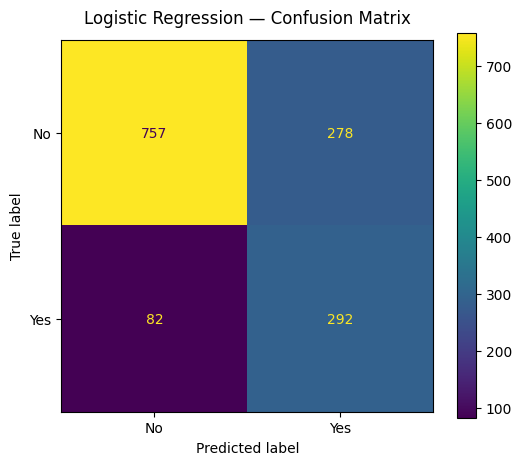

In [92]:
plot_confusion_matrix(
	best_logreg_clf,
	y_test,
	y_pred_logreg,
	'Logistic Regression — Confusion Matrix',
)

### ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve illustrates the model's ability to separate churned and retained customers across multiple classification thresholds.

The closer the curve approaches the top-left corner, the better the discriminative performance.

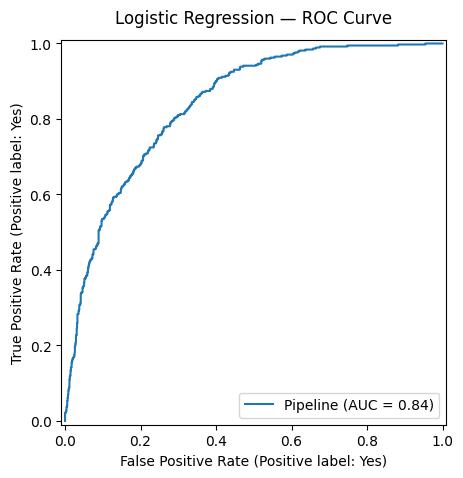

In [93]:
plot_roc_curve(
	best_logreg_clf,
	X_test,
	y_test,
	'Logistic Regression — ROC Curve',
)

## Model Export and Saved Artifacts

The best trained pipeline and training metadata are exported for downstream evaluation and deployment workflows.

The following artifacts are persisted:

- Best trained Logistic Regression pipeline
- Best hyperparameter configuration
- Best cross-validation ROC-AUC score

The exported pipeline includes both preprocessing and model steps, ensuring reproducible transformations during future inference.

In [94]:
base_logreg_path = '../models/logistic_regression'

logreg_artifacts = {
	'model_name': 'logistic_regression',
	'best_params': logreg_search.best_params_,
	'best_cv_score': logreg_search.best_score_,
	'best_index': logreg_search.best_index_,
	'test_metrics': logreg_metrics,
	'cv_strategy': {
		'type': 'RepeatedStratifiedKFold',
		'n_splits': RSKF_N_SPLITS,
		'n_repeats': RSKF_N_REPEATS,
	},
	'random_state': RANDOM_STATE,
}

save_artifacts(base_logreg_path, logreg_artifacts, best_logreg_clf)

# Decision Tree

This section trains an optimized Decision Tree classifier using **Optuna** for hyperparameter search.

Unlike Logistic Regression, which uses `RandomizedSearchCV` with a predefined parameter distribution, the Decision Tree leverages Optuna's Bayesian optimization to efficiently navigate a wider search space.

Numeric features are passed through without scaling since Decision Trees are invariant to feature magnitude.

## Pipeline Definition

The Decision Tree pipeline differs from the Logistic Regression pipeline in one important way: numerical features are passed through **without scaling**.

Decision Trees partition the feature space by thresholds, so the absolute scale of a feature does not affect the result. Applying `StandardScaler` would add unnecessary computation with no benefit.

The pipeline is rebuilt inside the Optuna objective on each trial to avoid state leakage when `memory` caching is active.

## Optuna Objective Function

The objective function defines the **search space** and **evaluation strategy** for each trial.

For each trial, Optuna suggests a combination of hyperparameters. A full pipeline, preprocessor + classifier, is assembled and evaluated using the shared `RepeatedStratifiedKFold` cross-validation strategy.

The mean ROC-AUC across all folds is returned as the objective value to maximize.

In [95]:
def objective(trial):
	criterion = trial.suggest_categorical(
		'criterion',
		['gini', 'entropy', 'log_loss'],
	)

	max_depth = trial.suggest_int(
		'max_depth',
		3,
		15,
	)

	min_samples_leaf = trial.suggest_int(
		'min_samples_leaf',
		5,
		100,
	)

	min_samples_split = trial.suggest_int(
		'min_samples_split',
		10,
		100,
	)

	max_features = trial.suggest_float(
		'max_features',
		0.3,
		1.0,
	)

	dt_clf = DecisionTreeClassifier(
		criterion=criterion,
		max_depth=max_depth,
		min_samples_split=min_samples_split,
		min_samples_leaf=min_samples_leaf,
		max_features=max_features,
		random_state=RANDOM_STATE,
		class_weight='balanced',
	)

	dt_prep = ColumnTransformer(
		transformers=[
			('num', 'passthrough', num_cols),
			('cat', cat_pipe, cat_cols),
		],
	)

	dt_pipe = Pipeline(
		steps=[
			('prep', dt_prep),
			('clf', dt_clf),
		],
		memory=memory,
	)

	scores = cross_val_score(
		dt_pipe,
		X_train,
		y_train,
		scoring='roc_auc',
		cv=rskf,
		n_jobs=1,
	)

	mean_roc_auc = scores.mean()

	return mean_roc_auc

## Optuna Study Configuration

A new Optuna study is created with `direction='maximize'` to find the hyperparameter configuration that yields the highest mean cross-validation ROC-AUC.

Setting `gc_after_trial=True` releases trial memory between runs, which prevents accumulation when fitting many pipelines.

In [96]:
dt_study = optuna.create_study(direction='maximize')

[I 2026-05-23 16:49:30,065] A new study created in memory with name: no-name-a1cfa4cd-fa17-4929-a395-fa441d07ba5d


In [97]:
dt_study.optimize(
	objective,
	n_trials=100,
	n_jobs=-1,
	gc_after_trial=True,
	show_progress_bar=True,
)

Best trial: 6. Best value: 0.82885:   1%|          | 1/100 [00:12<21:19, 12.93s/it]

[I 2026-05-23 16:49:42,865] Trial 15 finished with value: 0.8199148921264066 and parameters: {'criterion': 'log_loss', 'max_depth': 5, 'min_samples_leaf': 52, 'min_samples_split': 29, 'max_features': 0.35142879926638715}. Best is trial 15 with value: 0.8199148921264066.
[I 2026-05-23 16:49:42,901] Trial 6 finished with value: 0.8288503560118801 and parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 68, 'min_samples_split': 84, 'max_features': 0.564828737362612}. Best is trial 6 with value: 0.8288503560118801.


Best trial: 18. Best value: 0.833684:   3%|▎         | 3/100 [00:13<04:53,  3.03s/it]

[I 2026-05-23 16:49:42,985] Trial 16 finished with value: 0.8293068769988445 and parameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 83, 'min_samples_split': 44, 'max_features': 0.5232071945029518}. Best is trial 16 with value: 0.8293068769988445.
[I 2026-05-23 16:49:42,999] Trial 10 finished with value: 0.8274432382828023 and parameters: {'criterion': 'log_loss', 'max_depth': 4, 'min_samples_leaf': 14, 'min_samples_split': 63, 'max_features': 0.8352141481421997}. Best is trial 16 with value: 0.8293068769988445.
[I 2026-05-23 16:49:43,017] Trial 3 finished with value: 0.8256573435400498 and parameters: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 64, 'min_samples_split': 91, 'max_features': 0.3599762469365223}. Best is trial 16 with value: 0.8293068769988445.


Best trial: 11. Best value: 0.835232:   6%|▌         | 6/100 [00:13<01:25,  1.10it/s]

[I 2026-05-23 16:49:43,119] Trial 18 finished with value: 0.8336844278061422 and parameters: {'criterion': 'log_loss', 'max_depth': 8, 'min_samples_leaf': 88, 'min_samples_split': 90, 'max_features': 0.785902472464129}. Best is trial 18 with value: 0.8336844278061422.
[I 2026-05-23 16:49:43,143] Trial 21 finished with value: 0.8165741861989031 and parameters: {'criterion': 'log_loss', 'max_depth': 8, 'min_samples_leaf': 9, 'min_samples_split': 53, 'max_features': 0.34321879271590555}. Best is trial 18 with value: 0.8336844278061422.


Best trial: 11. Best value: 0.835232:   9%|▉         | 9/100 [00:13<00:35,  2.55it/s]

[I 2026-05-23 16:49:43,172] Trial 8 finished with value: 0.823721386604893 and parameters: {'criterion': 'log_loss', 'max_depth': 9, 'min_samples_leaf': 83, 'min_samples_split': 59, 'max_features': 0.34182309197966926}. Best is trial 18 with value: 0.8336844278061422.
[I 2026-05-23 16:49:43,273] Trial 12 finished with value: 0.8317403704341254 and parameters: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 89, 'min_samples_split': 73, 'max_features': 0.5680550771873535}. Best is trial 18 with value: 0.8336844278061422.
[I 2026-05-23 16:49:43,335] Trial 2 finished with value: 0.8285445524808769 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 60, 'min_samples_split': 36, 'max_features': 0.43972719480949707}. Best is trial 18 with value: 0.8336844278061422.


Best trial: 11. Best value: 0.835232:  12%|█▏        | 12/100 [00:14<00:23,  3.68it/s]

[I 2026-05-23 16:49:43,344] Trial 20 finished with value: 0.8189786653687995 and parameters: {'criterion': 'log_loss', 'max_depth': 12, 'min_samples_leaf': 22, 'min_samples_split': 15, 'max_features': 0.6415830017615828}. Best is trial 18 with value: 0.8336844278061422.
[I 2026-05-23 16:49:43,353] Trial 9 finished with value: 0.8284597274021549 and parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 81, 'min_samples_split': 11, 'max_features': 0.5027137293161851}. Best is trial 18 with value: 0.8336844278061422.
[I 2026-05-23 16:49:43,358] Trial 11 finished with value: 0.835231970820805 and parameters: {'criterion': 'log_loss', 'max_depth': 8, 'min_samples_leaf': 82, 'min_samples_split': 44, 'max_features': 0.7375349750077046}. Best is trial 11 with value: 0.835231970820805.


[I 2026-05-23 16:49:43,360] Trial 7 finished with value: 0.8272345848027188 and parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 35, 'min_samples_split': 57, 'max_features': 0.7703801708827611}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:43,360] Trial 17 finished with value: 0.822873632637955 and parameters: {'criterion': 'log_loss', 'max_depth': 14, 'min_samples_leaf': 17, 'min_samples_split': 93, 'max_features': 0.4473186938152034}. Best is trial 11 with value: 0.835231970820805.


[I 2026-05-23 16:49:43,541] Trial 4 finished with value: 0.8294802670818311 and parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 69, 'min_samples_split': 72, 'max_features': 0.461167929370081}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:43,551] Trial 14 finished with value: 0.8297435621967318 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 33, 'min_samples_split': 82, 'max_features': 0.8608228024775455}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  18%|█▊        | 18/100 [00:14<00:13,  6.23it/s]

[I 2026-05-23 16:49:43,572] Trial 13 finished with value: 0.8264818155278357 and parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 78, 'min_samples_split': 50, 'max_features': 0.6241365998565906}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:43,583] Trial 0 finished with value: 0.8155878815002942 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 19, 'min_samples_split': 92, 'max_features': 0.3154065978324715}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:43,659] Trial 5 finished with value: 0.8335649542504322 and parameters: {'criterion': 'gini', 'max_depth': 14, 'min_samples_leaf': 90, 'min_samples_split': 52, 'max_features': 0.5416868289881464}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  20%|██        | 20/100 [00:15<00:12,  6.43it/s]

[I 2026-05-23 16:49:43,731] Trial 23 finished with value: 0.8249200791411461 and parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 88, 'min_samples_split': 57, 'max_features': 0.7440255661737357}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:44,074] Trial 1 finished with value: 0.813920751616605 and parameters: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 10, 'min_samples_split': 56, 'max_features': 0.8082773196184856}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  23%|██▎       | 23/100 [00:15<00:09,  8.31it/s]

[I 2026-05-23 16:49:44,111] Trial 22 finished with value: 0.8256363835070437 and parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 9, 'min_samples_split': 90, 'max_features': 0.803901667001724}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:44,398] Trial 19 finished with value: 0.8293855524857414 and parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 40, 'min_samples_split': 53, 'max_features': 0.9138732555605766}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  25%|██▌       | 25/100 [00:27<03:13,  2.58s/it]

[I 2026-05-23 16:49:57,278] Trial 24 finished with value: 0.7838484023340121 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 17, 'max_features': 0.6654185049508128}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:57,280] Trial 29 finished with value: 0.8340704340140319 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 100, 'min_samples_split': 27, 'max_features': 0.9996778836429518}. Best is trial 11 with value: 0.835231970820805.


[I 2026-05-23 16:49:57,544] Trial 26 finished with value: 0.8331573390954327 and parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 99, 'min_samples_split': 76, 'max_features': 0.8254338644555016}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  28%|██▊       | 28/100 [00:27<01:28,  1.23s/it]

[I 2026-05-23 16:49:57,748] Trial 27 finished with value: 0.832497180403259 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 93, 'min_samples_split': 100, 'max_features': 0.9505539683466413}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:57,765] Trial 25 finished with value: 0.8199183599046223 and parameters: {'criterion': 'gini', 'max_depth': 11, 'min_samples_leaf': 10, 'min_samples_split': 76, 'max_features': 0.7267025465346013}. Best is trial 11 with value: 0.835231970820805.


[I 2026-05-23 16:49:57,784] Trial 33 finished with value: 0.8338737611704218 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 99, 'min_samples_split': 38, 'max_features': 0.9506623259442324}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:57,874] Trial 30 finished with value: 0.8330966927340044 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 95, 'min_samples_split': 36, 'max_features': 0.9513763595416701}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  32%|███▏      | 32/100 [00:28<00:29,  2.34it/s]

[I 2026-05-23 16:49:57,905] Trial 32 finished with value: 0.8335868481414594 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 98, 'min_samples_split': 39, 'max_features': 0.9537559373749869}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:58,031] Trial 31 finished with value: 0.8336917333891617 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 99, 'min_samples_split': 31, 'max_features': 0.9653423578509357}. Best is trial 11 with value: 0.835231970820805.


[I 2026-05-23 16:49:58,118] Trial 28 finished with value: 0.8342719266786258 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 99, 'min_samples_split': 99, 'max_features': 0.9841978377798701}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:58,332] Trial 35 finished with value: 0.8338737611704218 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 99, 'min_samples_split': 39, 'max_features': 0.9483281989238316}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  36%|███▌      | 36/100 [00:28<00:14,  4.55it/s]

[I 2026-05-23 16:49:58,593] Trial 37 finished with value: 0.833607017032613 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 98, 'min_samples_split': 39, 'max_features': 0.9716131064256548}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:58,713] Trial 39 finished with value: 0.8306370924967419 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 100, 'min_samples_split': 33, 'max_features': 0.7101651898276744}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  38%|███▊      | 38/100 [00:29<00:12,  4.77it/s]

[I 2026-05-23 16:49:58,720] Trial 36 finished with value: 0.8335770736957183 and parameters: {'criterion': 'log_loss', 'max_depth': 11, 'min_samples_leaf': 97, 'min_samples_split': 39, 'max_features': 0.966606530853623}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:58,844] Trial 34 finished with value: 0.8341591370456379 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 100, 'min_samples_split': 40, 'max_features': 0.9583713334735378}. Best is trial 11 with value: 0.835231970820805.


[I 2026-05-23 16:49:59,306] Trial 38 finished with value: 0.8306370924967419 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 100, 'min_samples_split': 38, 'max_features': 0.7204069880728161}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:59,313] Trial 41 finished with value: 0.8338199583471971 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 100, 'min_samples_split': 41, 'max_features': 0.6964083053894251}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  42%|████▏     | 42/100 [00:29<00:09,  6.43it/s]

[I 2026-05-23 16:49:59,347] Trial 40 finished with value: 0.8319267874457675 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 96, 'min_samples_split': 39, 'max_features': 0.716814984379566}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:59,434] Trial 46 finished with value: 0.831555701964175 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 94, 'min_samples_split': 38, 'max_features': 0.7114828156333264}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  44%|████▍     | 44/100 [00:29<00:09,  6.08it/s]

[I 2026-05-23 16:49:59,531] Trial 47 finished with value: 0.8345844158906608 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 95, 'min_samples_split': 40, 'max_features': 0.9957207528876441}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:59,790] Trial 43 finished with value: 0.8330677789853462 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 94, 'min_samples_split': 41, 'max_features': 0.6964161877100017}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  46%|████▌     | 46/100 [00:30<00:07,  6.76it/s]

[I 2026-05-23 16:49:59,821] Trial 45 finished with value: 0.8320938717403839 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 98, 'min_samples_split': 39, 'max_features': 0.719405485401021}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:49:59,841] Trial 44 finished with value: 0.8320938717403839 and parameters: {'criterion': 'log_loss', 'max_depth': 11, 'min_samples_leaf': 98, 'min_samples_split': 39, 'max_features': 0.7122133343772867}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  48%|████▊     | 48/100 [00:30<00:08,  6.19it/s]

[I 2026-05-23 16:50:00,074] Trial 42 finished with value: 0.8319212035413693 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 95, 'min_samples_split': 39, 'max_features': 0.7093146961429272}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  49%|████▉     | 49/100 [00:41<02:22,  2.80s/it]

[I 2026-05-23 16:50:11,840] Trial 49 finished with value: 0.8340549335338275 and parameters: {'criterion': 'log_loss', 'max_depth': 11, 'min_samples_leaf': 98, 'min_samples_split': 27, 'max_features': 0.9811261141972636}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  50%|█████     | 50/100 [00:42<01:48,  2.18s/it]

[I 2026-05-23 16:50:12,110] Trial 50 finished with value: 0.8332977373225795 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 97, 'min_samples_split': 24, 'max_features': 0.9644177522745353}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:12,147] Trial 51 finished with value: 0.834066464238288 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 74, 'min_samples_split': 26, 'max_features': 0.9967942948936838}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  52%|█████▏    | 52/100 [00:42<01:00,  1.26s/it]

[I 2026-05-23 16:50:12,446] Trial 48 finished with value: 0.8336917333891617 and parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 99, 'min_samples_split': 27, 'max_features': 0.9549156551613789}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:12,454] Trial 52 finished with value: 0.8329783041532984 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 74, 'min_samples_split': 25, 'max_features': 0.9008411871279155}. Best is trial 11 with value: 0.835231970820805.


[I 2026-05-23 16:50:12,854] Trial 55 finished with value: 0.8328008389913311 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 73, 'min_samples_split': 24, 'max_features': 0.8893532833064729}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:12,904] Trial 53 finished with value: 0.8336388115769715 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 75, 'min_samples_split': 27, 'max_features': 0.9977050270942374}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  55%|█████▌    | 55/100 [00:43<00:26,  1.69it/s]

[I 2026-05-23 16:50:12,987] Trial 54 finished with value: 0.8335422804512004 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 75, 'min_samples_split': 24, 'max_features': 0.9066829042610941}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:12,997] Trial 56 finished with value: 0.834066464238288 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 74, 'min_samples_split': 27, 'max_features': 0.992722939577664}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  58%|█████▊    | 58/100 [00:43<00:12,  3.23it/s]

[I 2026-05-23 16:50:13,427] Trial 58 finished with value: 0.8330774807542707 and parameters: {'criterion': 'log_loss', 'max_depth': 6, 'min_samples_leaf': 76, 'min_samples_split': 23, 'max_features': 0.9092510051920634}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  59%|█████▉    | 59/100 [00:43<00:12,  3.27it/s]

[I 2026-05-23 16:50:13,659] Trial 57 finished with value: 0.8345329559179355 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 74, 'min_samples_split': 22, 'max_features': 0.8790220826813051}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:13,814] Trial 59 finished with value: 0.8335422804512004 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 75, 'min_samples_split': 24, 'max_features': 0.8954328343424636}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  61%|██████    | 61/100 [00:44<00:07,  5.10it/s]

[I 2026-05-23 16:50:13,823] Trial 61 finished with value: 0.8345329559179355 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 74, 'min_samples_split': 22, 'max_features': 0.8845455269730801}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:14,131] Trial 62 finished with value: 0.8332755277172089 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 72, 'min_samples_split': 27, 'max_features': 0.9019555750780364}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  63%|██████▎   | 63/100 [00:44<00:07,  4.98it/s]

[I 2026-05-23 16:50:14,143] Trial 60 finished with value: 0.8323317789090745 and parameters: {'criterion': 'log_loss', 'max_depth': 6, 'min_samples_leaf': 74, 'min_samples_split': 26, 'max_features': 0.893700082545503}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:14,145] Trial 63 finished with value: 0.8329783041532984 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 74, 'min_samples_split': 27, 'max_features': 0.8944131524451766}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  65%|██████▌   | 65/100 [00:44<00:06,  5.17it/s]

[I 2026-05-23 16:50:14,296] Trial 64 finished with value: 0.833782234878929 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 76, 'min_samples_split': 25, 'max_features': 0.9027869803843189}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:14,413] Trial 66 finished with value: 0.8336220235253684 and parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 77, 'min_samples_split': 25, 'max_features': 0.8970833026725344}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  66%|██████▌   | 66/100 [00:44<00:06,  5.17it/s]

[I 2026-05-23 16:50:14,527] Trial 70 finished with value: 0.8348221392182643 and parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 77, 'min_samples_split': 24, 'max_features': 0.8852530840063337}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:14,810] Trial 68 finished with value: 0.833782234878929 and parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 76, 'min_samples_split': 25, 'max_features': 0.8874041057762453}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  68%|██████▊   | 68/100 [00:45<00:05,  6.23it/s]

[I 2026-05-23 16:50:14,929] Trial 69 finished with value: 0.8331701927328613 and parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 77, 'min_samples_split': 25, 'max_features': 0.999517661813223}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:14,952] Trial 67 finished with value: 0.833782234878929 and parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 76, 'min_samples_split': 25, 'max_features': 0.9029314656122789}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  71%|███████   | 71/100 [00:45<00:04,  6.64it/s]

[I 2026-05-23 16:50:15,026] Trial 65 finished with value: 0.833782234878929 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 76, 'min_samples_split': 25, 'max_features': 0.8919214480524655}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  72%|███████▏  | 72/100 [00:45<00:04,  5.87it/s]

[I 2026-05-23 16:50:15,582] Trial 71 finished with value: 0.8325041989909997 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 75, 'min_samples_split': 22, 'max_features': 0.8893035812147319}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  73%|███████▎  | 73/100 [00:57<01:25,  3.15s/it]

[I 2026-05-23 16:50:26,913] Trial 72 finished with value: 0.8334350468827009 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 74, 'min_samples_split': 24, 'max_features': 0.8920278427785291}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:27,132] Trial 74 finished with value: 0.8344379271704448 and parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 78, 'min_samples_split': 47, 'max_features': 0.8981278692331367}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  75%|███████▌  | 75/100 [00:57<00:42,  1.72s/it]

[I 2026-05-23 16:50:27,256] Trial 73 finished with value: 0.8328008389913311 and parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 73, 'min_samples_split': 47, 'max_features': 0.9017895112872194}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:27,429] Trial 75 finished with value: 0.8334316743462812 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 78, 'min_samples_split': 45, 'max_features': 0.9966253832329879}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  77%|███████▋  | 77/100 [00:57<00:21,  1.06it/s]

[I 2026-05-23 16:50:27,455] Trial 77 finished with value: 0.8342236662441448 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 85, 'min_samples_split': 62, 'max_features': 0.8660276707224438}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:27,467] Trial 76 finished with value: 0.8327261894484163 and parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 79, 'min_samples_split': 48, 'max_features': 0.8986375385743547}. Best is trial 11 with value: 0.835231970820805.


[I 2026-05-23 16:50:27,869] Trial 80 finished with value: 0.8342236662441448 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 85, 'min_samples_split': 47, 'max_features': 0.8647997180050125}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  80%|████████  | 80/100 [00:58<00:08,  2.28it/s]

[I 2026-05-23 16:50:28,073] Trial 78 finished with value: 0.8342236662441448 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 85, 'min_samples_split': 20, 'max_features': 0.8799690251948655}. Best is trial 11 with value: 0.835231970820805.


Best trial: 11. Best value: 0.835232:  81%|████████  | 81/100 [00:58<00:07,  2.58it/s]

[I 2026-05-23 16:50:28,322] Trial 82 finished with value: 0.832744441293162 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 60, 'min_samples_split': 18, 'max_features': 0.931931790517499}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:28,349] Trial 79 finished with value: 0.8342236662441448 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 85, 'min_samples_split': 47, 'max_features': 0.866966812303671}. Best is trial 11 with value: 0.835231970820805.


Best trial: 84. Best value: 0.835577:  83%|████████▎ | 83/100 [00:58<00:04,  3.68it/s]

[I 2026-05-23 16:50:28,550] Trial 85 finished with value: 0.8329324408815612 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 85, 'min_samples_split': 47, 'max_features': 0.8631244563537757}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:28,561] Trial 83 finished with value: 0.8337491085123677 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 57, 'min_samples_split': 48, 'max_features': 0.8553464170793074}. Best is trial 11 with value: 0.835231970820805.
[I 2026-05-23 16:50:28,659] Trial 87 finished with value: 0.83246071490817 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 63, 'min_samples_split': 49, 'max_features': 0.8620727140389696}. Best is trial 11 with value: 0.835231970820805.


Best trial: 84. Best value: 0.835577:  87%|████████▋ | 87/100 [00:59<00:02,  4.96it/s]

[I 2026-05-23 16:50:28,660] Trial 84 finished with value: 0.8355773989440096 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 56, 'min_samples_split': 63, 'max_features': 0.8688682398044445}. Best is trial 84 with value: 0.8355773989440096.
[I 2026-05-23 16:50:28,661] Trial 81 finished with value: 0.8342236662441448 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 85, 'min_samples_split': 47, 'max_features': 0.8662270826964684}. Best is trial 84 with value: 0.8355773989440096.
[I 2026-05-23 16:50:28,866] Trial 86 finished with value: 0.8336720635650194 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 62, 'min_samples_split': 48, 'max_features': 0.8376614120591748}. Best is trial 84 with value: 0.8355773989440096.


Best trial: 84. Best value: 0.835577:  90%|█████████ | 90/100 [00:59<00:01,  6.27it/s]

[I 2026-05-23 16:50:29,178] Trial 89 finished with value: 0.8334841480824525 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 62, 'min_samples_split': 46, 'max_features': 0.850808703814137}. Best is trial 84 with value: 0.8355773989440096.
[I 2026-05-23 16:50:29,273] Trial 92 finished with value: 0.8326297837487644 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 65, 'min_samples_split': 48, 'max_features': 0.8452404556241934}. Best is trial 84 with value: 0.8355773989440096.
[I 2026-05-23 16:50:29,275] Trial 88 finished with value: 0.83246071490817 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 63, 'min_samples_split': 48, 'max_features': 0.850413478410188}. Best is trial 84 with value: 0.8355773989440096.


Best trial: 84. Best value: 0.835577:  92%|█████████▏| 92/100 [00:59<00:01,  7.46it/s]

[I 2026-05-23 16:50:29,452] Trial 90 finished with value: 0.8334841480824525 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 62, 'min_samples_split': 45, 'max_features': 0.8596127139348726}. Best is trial 84 with value: 0.8355773989440096.
[I 2026-05-23 16:50:29,595] Trial 91 finished with value: 0.8334900596186291 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 61, 'min_samples_split': 47, 'max_features': 0.8427296005342584}. Best is trial 84 with value: 0.8355773989440096.


Best trial: 84. Best value: 0.835577:  96%|█████████▌| 96/100 [00:59<00:00, 11.86it/s]

[I 2026-05-23 16:50:29,615] Trial 93 finished with value: 0.8334841480824525 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 62, 'min_samples_split': 46, 'max_features': 0.8565649500274894}. Best is trial 84 with value: 0.8355773989440096.
[I 2026-05-23 16:50:29,618] Trial 95 finished with value: 0.834369562023128 and parameters: {'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 84, 'min_samples_split': 47, 'max_features': 0.850723629127499}. Best is trial 84 with value: 0.8355773989440096.
[I 2026-05-23 16:50:29,737] Trial 94 finished with value: 0.8327933395057832 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 60, 'min_samples_split': 20, 'max_features': 0.8457919870821685}. Best is trial 84 with value: 0.8355773989440096.


Best trial: 84. Best value: 0.835577:  98%|█████████▊| 98/100 [01:01<00:00,  3.34it/s]

[I 2026-05-23 16:50:31,404] Trial 96 finished with value: 0.8339993597992995 and parameters: {'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 85, 'min_samples_split': 48, 'max_features': 0.8593081203716001}. Best is trial 84 with value: 0.8355773989440096.
[I 2026-05-23 16:50:31,495] Trial 97 finished with value: 0.8330823463890007 and parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 62, 'min_samples_split': 49, 'max_features': 0.8524034536251378}. Best is trial 84 with value: 0.8355773989440096.
[I 2026-05-23 16:50:31,579] Trial 99 finished with value: 0.8332795800358427 and parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 61, 'min_samples_split': 63, 'max_features': 0.8507869784646912}. Best is trial 84 with value: 0.8355773989440096.


Best trial: 84. Best value: 0.835577: 100%|██████████| 100/100 [01:01<00:00,  1.62it/s]

[I 2026-05-23 16:50:31,640] Trial 98 finished with value: 0.8335877873720944 and parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 84, 'min_samples_split': 64, 'max_features': 0.8474305565543564}. Best is trial 84 with value: 0.8355773989440096.


## Best Hyperparameters

The best Decision Tree configuration identified by Optuna is analyzed below.

In [98]:
display(dt_study.best_params)

{'criterion': 'entropy',
 'max_depth': 9,
 'min_samples_leaf': 56,
 'min_samples_split': 63,
 'max_features': 0.8688682398044445}

## Cross-Validation Performance

The best mean ROC-AUC score obtained during hyperparameter optimization is displayed below.

In [99]:
display(dt_study.best_value)

0.8355773989440096

## Best Pipeline Reconstruction

Optuna stores only the best **hyperparameter values**, not the fitted pipeline.

The best configuration is used to manually reconstruct and refit the Decision Tree pipeline on the full training set before evaluation on the held-out test set.

In [100]:
best_dt_clf = DecisionTreeClassifier(
	**dt_study.best_params,
	random_state=RANDOM_STATE,
	class_weight='balanced',
)

In [101]:
best_dt_prep = ColumnTransformer(
	transformers=[
		('num', 'passthrough', num_cols),
		('cat', cat_pipe, cat_cols),
	],
)

In [102]:
best_dt_pipe = Pipeline(
	steps=[
		('prep', best_dt_prep),
		('clf', best_dt_clf),
	],
	memory=memory,
)

In [103]:
best_dt_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(locati.../cache/joblib)
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

## Test Set Inference

The optimized Decision Tree pipeline is applied to the unseen test set to evaluate generalization performance. 

Both class predictions and predicted probabilities are generated for downstream metric evaluation.

In [104]:
y_pred_dt = best_dt_pipe.predict(X_test)

y_proba_dt = best_dt_pipe.predict_proba(X_test)[:, 1]

## Model Evaluation Metrics

The optimized Decision Tree model is evaluated using multiple classification metrics on the test set.

These metrics help analyze:

- Overall predictive performance
- Churn detection capability
- Balance between false positives and false negatives

In [105]:
dt_metrics = compute_metrics(y_test, y_pred_dt, y_proba_dt)

print_metrics(dt_metrics)

ROC-AUC  : 0.8389
Accuracy : 0.7587
Precision: 0.5307
Recall   : 0.7861
F1-Score : 0.6336


### Classification Report

A detailed classification report summarizes Decision Tree performance across both churn classes.

In [106]:
display(build_classification_report(y_test, y_pred_dt))

,precision,recall,f1-score,support
No,0.906433,0.748792,0.820106,1035.000000
Yes,0.530686,0.786096,0.633621,374.000000
accuracy,0.758694,0.758694,0.758694,0.758694
macro avg,0.718559,0.767444,0.726863,1409.000000


### Confusion Matrix Analysis

The confusion matrix provides a detailed overview of correct and incorrect predictions produced by the Decision Tree classifier.

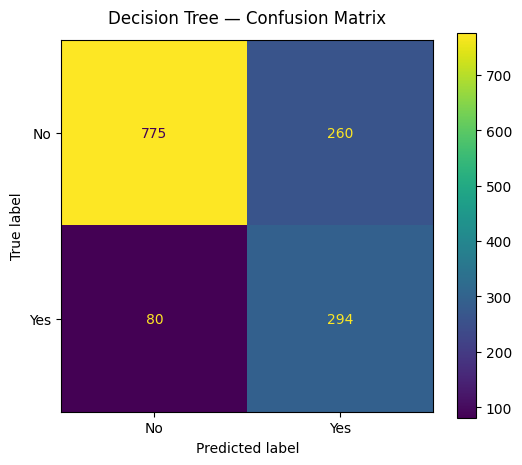

In [107]:
plot_confusion_matrix(
	best_dt_pipe,
	y_test,
	y_pred_dt,
	'Decision Tree — Confusion Matrix',
)

### ROC Curve Analysis

The ROC curve illustrates the Decision Tree classifier's discriminative capability across multiple classification thresholds.

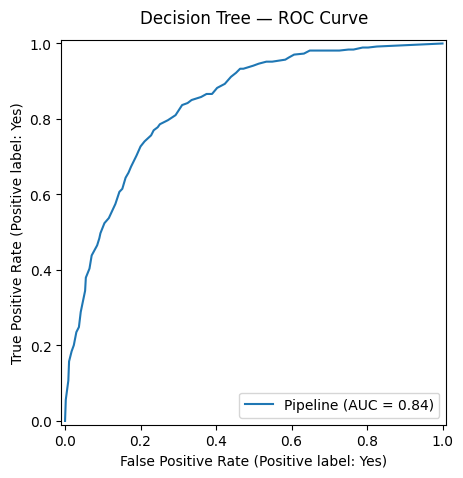

In [108]:
plot_roc_curve(
	best_dt_pipe,
	X_test,
	y_test,
	'Decision Tree — ROC Curve',
)

## Model Export and Saved Artifacts

The optimized Decision Tree pipeline and training metadata are exported for future inference and deployment workflows.

In [109]:
base_dt_path = '../models/decision_tree'

dt_artifacts = {
	'model_name': 'decision_tree',
	'best_params': dt_study.best_params,
	'best_cv_score': dt_study.best_value,
	'test_metrics': dt_metrics,
	'cv_strategy': {
		'type': 'RepeatedStratifiedKFold',
		'n_splits': RSKF_N_SPLITS,
		'n_repeats': RSKF_N_REPEATS,
	},
	'random_state': RANDOM_STATE,
}

save_artifacts(base_dt_path, dt_artifacts, best_dt_pipe)

# Random Forest

In [110]:
def objective(trial):
	criterion = trial.suggest_categorical(
		'criterion',
		['gini', 'entropy', 'log_loss'],
	)

	n_estimators = trial.suggest_int(
		'n_estimators',
		50,
		300,
	)

	max_depth = trial.suggest_int(
		'max_depth',
		2,
		30,
	)

	min_samples_leaf = trial.suggest_int(
		'min_samples_leaf',
		1,
		30,
	)

	max_features = trial.suggest_float(
		'max_features',
		0.3,
		1.0,
	)

	class_weight = trial.suggest_categorical(
		'class_weight',
		['balanced', 'balanced_subsample'],
	)

	rf_clf = RandomForestClassifier(
		n_estimators=n_estimators,
		criterion=criterion,
		max_depth=max_depth,
		min_samples_leaf=min_samples_leaf,
		max_features=max_features,
		class_weight=class_weight,
		random_state=RANDOM_STATE,
		n_jobs=1,
	)

	rf_prep = ColumnTransformer(
		transformers=[
			('num', 'passthrough', num_cols),
			('cat', cat_pipe, cat_cols),
		]
	)

	rf_pipe = Pipeline(
		steps=[
			('prep', rf_prep),
			('clf', rf_clf),
		],
		memory=memory,
	)

	scores = cross_val_score(
		rf_pipe,
		X_train,
		y_train,
		scoring='roc_auc',
		cv=rskf,
		n_jobs=1,
	)

	mean_roc_auc = scores.mean()

	return mean_roc_auc

In [111]:
rf_study = optuna.create_study(direction='maximize')

[I 2026-05-23 16:50:31,997] A new study created in memory with name: no-name-0ae5e3de-1a86-46e3-910a-446739d30bfd


In [112]:
rf_study.optimize(
	objective,
	n_trials=100,
	n_jobs=-1,
	gc_after_trial=True,
	show_progress_bar=True,
)

Best trial: 23. Best value: 0.84756:   1%|          | 1/100 [00:38<1:03:46, 38.65s/it]

[I 2026-05-23 16:51:10,546] Trial 23 finished with value: 0.8475604873808917 and parameters: {'criterion': 'entropy', 'n_estimators': 60, 'max_depth': 25, 'min_samples_leaf': 25, 'max_features': 0.3873886794737454, 'class_weight': 'balanced'}. Best is trial 23 with value: 0.8475604873808917.


Best trial: 23. Best value: 0.84756:   2%|▏         | 2/100 [00:41<29:11, 17.88s/it]  

[I 2026-05-23 16:51:13,893] Trial 22 finished with value: 0.8474002272830684 and parameters: {'criterion': 'entropy', 'n_estimators': 65, 'max_depth': 16, 'min_samples_leaf': 24, 'max_features': 0.4963844583142014, 'class_weight': 'balanced'}. Best is trial 23 with value: 0.8475604873808917.


Best trial: 23. Best value: 0.84756:   3%|▎         | 3/100 [00:56<26:41, 16.51s/it]

[I 2026-05-23 16:51:28,758] Trial 13 finished with value: 0.8472962425831796 and parameters: {'criterion': 'gini', 'n_estimators': 52, 'max_depth': 16, 'min_samples_leaf': 25, 'max_features': 0.3189605668520166, 'class_weight': 'balanced_subsample'}. Best is trial 23 with value: 0.8475604873808917.


Best trial: 23. Best value: 0.84756:   4%|▍         | 4/100 [01:08<23:36, 14.76s/it]

[I 2026-05-23 16:51:40,861] Trial 20 finished with value: 0.8444871100339314 and parameters: {'criterion': 'gini', 'n_estimators': 62, 'max_depth': 13, 'min_samples_leaf': 9, 'max_features': 0.520342365355626, 'class_weight': 'balanced_subsample'}. Best is trial 23 with value: 0.8475604873808917.


Best trial: 23. Best value: 0.84756:   5%|▌         | 5/100 [01:44<35:01, 22.12s/it]

[I 2026-05-23 16:52:16,005] Trial 8 finished with value: 0.8449233800752717 and parameters: {'criterion': 'log_loss', 'n_estimators': 92, 'max_depth': 29, 'min_samples_leaf': 14, 'max_features': 0.88933861162298, 'class_weight': 'balanced_subsample'}. Best is trial 23 with value: 0.8475604873808917.


Best trial: 23. Best value: 0.84756:   6%|▌         | 6/100 [01:53<27:47, 17.73s/it]

[I 2026-05-23 16:52:25,250] Trial 4 finished with value: 0.8471547681725792 and parameters: {'criterion': 'gini', 'n_estimators': 186, 'max_depth': 20, 'min_samples_leaf': 19, 'max_features': 0.77931566134133, 'class_weight': 'balanced'}. Best is trial 23 with value: 0.8475604873808917.


Best trial: 23. Best value: 0.84756:   7%|▋         | 7/100 [01:57<20:26, 13.19s/it]

[I 2026-05-23 16:52:29,080] Trial 17 finished with value: 0.8378966403207346 and parameters: {'criterion': 'log_loss', 'n_estimators': 167, 'max_depth': 20, 'min_samples_leaf': 5, 'max_features': 0.9874178430249014, 'class_weight': 'balanced'}. Best is trial 23 with value: 0.8475604873808917.


Best trial: 16. Best value: 0.847707:   8%|▊         | 8/100 [01:59<14:51,  9.69s/it]

[I 2026-05-23 16:52:31,280] Trial 16 finished with value: 0.8477068434463807 and parameters: {'criterion': 'gini', 'n_estimators': 204, 'max_depth': 13, 'min_samples_leaf': 23, 'max_features': 0.6289428985267147, 'class_weight': 'balanced'}. Best is trial 16 with value: 0.8477068434463807.


Best trial: 18. Best value: 0.848058:   9%|▉         | 9/100 [02:01<11:10,  7.37s/it]

[I 2026-05-23 16:52:33,543] Trial 18 finished with value: 0.8480578673914186 and parameters: {'criterion': 'log_loss', 'n_estimators': 119, 'max_depth': 15, 'min_samples_leaf': 21, 'max_features': 0.3235227427348138, 'class_weight': 'balanced_subsample'}. Best is trial 18 with value: 0.8480578673914186.


Best trial: 18. Best value: 0.848058:  10%|█         | 10/100 [02:15<14:09,  9.44s/it]

[I 2026-05-23 16:52:47,621] Trial 12 finished with value: 0.847940314203369 and parameters: {'criterion': 'gini', 'n_estimators': 245, 'max_depth': 13, 'min_samples_leaf': 22, 'max_features': 0.38827389187668687, 'class_weight': 'balanced'}. Best is trial 18 with value: 0.8480578673914186.


Best trial: 18. Best value: 0.848058:  11%|█         | 11/100 [02:17<10:43,  7.23s/it]

[I 2026-05-23 16:52:49,834] Trial 19 finished with value: 0.847502703255224 and parameters: {'criterion': 'gini', 'n_estimators': 131, 'max_depth': 6, 'min_samples_leaf': 28, 'max_features': 0.7467304265871701, 'class_weight': 'balanced_subsample'}. Best is trial 18 with value: 0.8480578673914186.


Best trial: 18. Best value: 0.848058:  12%|█▏        | 12/100 [02:31<13:20,  9.10s/it]

[I 2026-05-23 16:53:03,201] Trial 2 finished with value: 0.8477108442856026 and parameters: {'criterion': 'log_loss', 'n_estimators': 148, 'max_depth': 15, 'min_samples_leaf': 17, 'max_features': 0.34765854312823885, 'class_weight': 'balanced_subsample'}. Best is trial 18 with value: 0.8480578673914186.


Best trial: 18. Best value: 0.848058:  13%|█▎        | 13/100 [02:33<10:14,  7.06s/it]

[I 2026-05-23 16:53:05,546] Trial 29 finished with value: 0.8463670661605782 and parameters: {'criterion': 'gini', 'n_estimators': 62, 'max_depth': 10, 'min_samples_leaf': 12, 'max_features': 0.5203740422347188, 'class_weight': 'balanced'}. Best is trial 18 with value: 0.8480578673914186.


Best trial: 18. Best value: 0.848058:  14%|█▍        | 14/100 [02:38<08:58,  6.26s/it]

[I 2026-05-23 16:53:09,987] Trial 6 finished with value: 0.8471132155933736 and parameters: {'criterion': 'gini', 'n_estimators': 256, 'max_depth': 16, 'min_samples_leaf': 21, 'max_features': 0.8779138403532079, 'class_weight': 'balanced'}. Best is trial 18 with value: 0.8480578673914186.


Best trial: 18. Best value: 0.848058:  15%|█▌        | 15/100 [02:46<09:53,  6.98s/it]

[I 2026-05-23 16:53:18,631] Trial 7 finished with value: 0.847461708255682 and parameters: {'criterion': 'gini', 'n_estimators': 289, 'max_depth': 15, 'min_samples_leaf': 20, 'max_features': 0.6314570413156195, 'class_weight': 'balanced'}. Best is trial 18 with value: 0.8480578673914186.


Best trial: 18. Best value: 0.848058:  16%|█▌        | 16/100 [02:47<06:59,  5.00s/it]

[I 2026-05-23 16:53:19,028] Trial 1 finished with value: 0.8419080708210571 and parameters: {'criterion': 'entropy', 'n_estimators': 169, 'max_depth': 4, 'min_samples_leaf': 11, 'max_features': 0.43305717495320106, 'class_weight': 'balanced_subsample'}. Best is trial 18 with value: 0.8480578673914186.


Best trial: 18. Best value: 0.848058:  17%|█▋        | 17/100 [02:51<06:36,  4.78s/it]

[I 2026-05-23 16:53:23,300] Trial 24 finished with value: 0.8479110119658667 and parameters: {'criterion': 'entropy', 'n_estimators': 222, 'max_depth': 14, 'min_samples_leaf': 25, 'max_features': 0.7235922076421325, 'class_weight': 'balanced'}. Best is trial 18 with value: 0.8480578673914186.


Best trial: 18. Best value: 0.848058:  18%|█▊        | 18/100 [02:53<05:34,  4.08s/it]

[I 2026-05-23 16:53:25,758] Trial 25 finished with value: 0.8480361432749981 and parameters: {'criterion': 'entropy', 'n_estimators': 245, 'max_depth': 29, 'min_samples_leaf': 28, 'max_features': 0.3038756448717701, 'class_weight': 'balanced'}. Best is trial 18 with value: 0.8480578673914186.


Best trial: 18. Best value: 0.848058:  19%|█▉        | 19/100 [02:54<04:04,  3.01s/it]

[I 2026-05-23 16:53:26,272] Trial 10 finished with value: 0.8476068767780789 and parameters: {'criterion': 'gini', 'n_estimators': 168, 'max_depth': 26, 'min_samples_leaf': 21, 'max_features': 0.5744227254586283, 'class_weight': 'balanced_subsample'}. Best is trial 18 with value: 0.8480578673914186.


Best trial: 18. Best value: 0.848058:  20%|██        | 20/100 [02:57<04:11,  3.14s/it]

[I 2026-05-23 16:53:29,681] Trial 26 finished with value: 0.8457172082349632 and parameters: {'criterion': 'log_loss', 'n_estimators': 119, 'max_depth': 5, 'min_samples_leaf': 22, 'max_features': 0.4624584440859923, 'class_weight': 'balanced_subsample'}. Best is trial 18 with value: 0.8480578673914186.


Best trial: 18. Best value: 0.848058:  21%|██        | 21/100 [03:05<05:47,  4.40s/it]

[I 2026-05-23 16:53:37,060] Trial 0 finished with value: 0.8477709462546931 and parameters: {'criterion': 'gini', 'n_estimators': 177, 'max_depth': 18, 'min_samples_leaf': 28, 'max_features': 0.7286273596231887, 'class_weight': 'balanced_subsample'}. Best is trial 18 with value: 0.8480578673914186.


Best trial: 15. Best value: 0.848175:  22%|██▏       | 22/100 [03:06<04:39,  3.58s/it]

[I 2026-05-23 16:53:38,745] Trial 15 finished with value: 0.848174622795111 and parameters: {'criterion': 'log_loss', 'n_estimators': 183, 'max_depth': 18, 'min_samples_leaf': 26, 'max_features': 0.4366076070000892, 'class_weight': 'balanced_subsample'}. Best is trial 15 with value: 0.848174622795111.


Best trial: 15. Best value: 0.848175:  23%|██▎       | 23/100 [03:15<06:26,  5.02s/it]

[I 2026-05-23 16:53:47,102] Trial 9 finished with value: 0.8465544843344439 and parameters: {'criterion': 'gini', 'n_estimators': 184, 'max_depth': 10, 'min_samples_leaf': 14, 'max_features': 0.745801042698935, 'class_weight': 'balanced_subsample'}. Best is trial 15 with value: 0.848174622795111.


Best trial: 15. Best value: 0.848175:  24%|██▍       | 24/100 [03:18<05:33,  4.39s/it]

[I 2026-05-23 16:53:50,009] Trial 30 finished with value: 0.8473905827569055 and parameters: {'criterion': 'gini', 'n_estimators': 130, 'max_depth': 15, 'min_samples_leaf': 22, 'max_features': 0.7764738740523356, 'class_weight': 'balanced'}. Best is trial 15 with value: 0.848174622795111.


Best trial: 15. Best value: 0.848175:  25%|██▌       | 25/100 [03:24<06:04,  4.87s/it]

[I 2026-05-23 16:53:56,003] Trial 28 finished with value: 0.8316186820915005 and parameters: {'criterion': 'entropy', 'n_estimators': 161, 'max_depth': 14, 'min_samples_leaf': 1, 'max_features': 0.3867850137431865, 'class_weight': 'balanced'}. Best is trial 15 with value: 0.848174622795111.


Best trial: 3. Best value: 0.848217:  26%|██▌       | 26/100 [03:40<10:24,  8.43s/it] 

[I 2026-05-23 16:54:12,745] Trial 3 finished with value: 0.8482167638220902 and parameters: {'criterion': 'log_loss', 'n_estimators': 218, 'max_depth': 26, 'min_samples_leaf': 25, 'max_features': 0.4567843454678893, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  27%|██▋       | 27/100 [03:56<12:53, 10.59s/it]

[I 2026-05-23 16:54:28,372] Trial 27 finished with value: 0.8471993431891304 and parameters: {'criterion': 'gini', 'n_estimators': 165, 'max_depth': 19, 'min_samples_leaf': 14, 'max_features': 0.4623555718779067, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  28%|██▊       | 28/100 [04:08<13:22, 11.14s/it]

[I 2026-05-23 16:54:40,797] Trial 21 finished with value: 0.8467260941284731 and parameters: {'criterion': 'entropy', 'n_estimators': 243, 'max_depth': 17, 'min_samples_leaf': 14, 'max_features': 0.6015636181746822, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  29%|██▉       | 29/100 [04:11<10:09,  8.58s/it]

[I 2026-05-23 16:54:43,417] Trial 14 finished with value: 0.8461022076149637 and parameters: {'criterion': 'log_loss', 'n_estimators': 235, 'max_depth': 28, 'min_samples_leaf': 16, 'max_features': 0.8890392157296765, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  30%|███       | 30/100 [04:28<13:02, 11.18s/it]

[I 2026-05-23 16:55:00,660] Trial 11 finished with value: 0.8467792941443919 and parameters: {'criterion': 'log_loss', 'n_estimators': 260, 'max_depth': 12, 'min_samples_leaf': 16, 'max_features': 0.6899061220144602, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  31%|███       | 31/100 [04:31<10:03,  8.75s/it]

[I 2026-05-23 16:55:03,744] Trial 33 finished with value: 0.8430056926656452 and parameters: {'criterion': 'log_loss', 'n_estimators': 137, 'max_depth': 4, 'min_samples_leaf': 29, 'max_features': 0.6902493744800864, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  32%|███▏      | 32/100 [04:37<08:53,  7.85s/it]

[I 2026-05-23 16:55:09,417] Trial 40 finished with value: 0.8481904820682555 and parameters: {'criterion': 'log_loss', 'n_estimators': 107, 'max_depth': 9, 'min_samples_leaf': 30, 'max_features': 0.4390131252925443, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  33%|███▎      | 33/100 [04:42<07:41,  6.89s/it]

[I 2026-05-23 16:55:14,139] Trial 42 finished with value: 0.8479889932133333 and parameters: {'criterion': 'log_loss', 'n_estimators': 110, 'max_depth': 21, 'min_samples_leaf': 29, 'max_features': 0.3045100882848293, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  34%|███▍      | 34/100 [04:43<05:46,  5.25s/it]

[I 2026-05-23 16:55:15,546] Trial 32 finished with value: 0.847862762081246 and parameters: {'criterion': 'gini', 'n_estimators': 288, 'max_depth': 26, 'min_samples_leaf': 28, 'max_features': 0.6447363560853469, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  35%|███▌      | 35/100 [04:47<05:04,  4.69s/it]

[I 2026-05-23 16:55:18,939] Trial 41 finished with value: 0.8480165892062698 and parameters: {'criterion': 'log_loss', 'n_estimators': 113, 'max_depth': 21, 'min_samples_leaf': 30, 'max_features': 0.4653966241642532, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  36%|███▌      | 36/100 [04:52<05:09,  4.84s/it]

[I 2026-05-23 16:55:24,134] Trial 5 finished with value: 0.848075105179667 and parameters: {'criterion': 'entropy', 'n_estimators': 290, 'max_depth': 25, 'min_samples_leaf': 27, 'max_features': 0.5623913191341443, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  37%|███▋      | 37/100 [05:00<06:10,  5.88s/it]

[I 2026-05-23 16:55:32,392] Trial 48 finished with value: 0.8481172896759788 and parameters: {'criterion': 'log_loss', 'n_estimators': 97, 'max_depth': 23, 'min_samples_leaf': 29, 'max_features': 0.33916518576365956, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  38%|███▊      | 38/100 [05:09<07:07,  6.90s/it]

[I 2026-05-23 16:55:41,700] Trial 44 finished with value: 0.847951108664325 and parameters: {'criterion': 'log_loss', 'n_estimators': 243, 'max_depth': 8, 'min_samples_leaf': 28, 'max_features': 0.31495346816457703, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  39%|███▉      | 39/100 [06:00<20:23, 20.06s/it]

[I 2026-05-23 16:56:32,470] Trial 31 finished with value: 0.8468032053055013 and parameters: {'criterion': 'entropy', 'n_estimators': 236, 'max_depth': 19, 'min_samples_leaf': 16, 'max_features': 0.7270377548680648, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  40%|████      | 40/100 [06:10<17:03, 17.05s/it]

[I 2026-05-23 16:56:42,516] Trial 57 finished with value: 0.8479655959671869 and parameters: {'criterion': 'log_loss', 'n_estimators': 87, 'max_depth': 23, 'min_samples_leaf': 26, 'max_features': 0.41676873527601976, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  41%|████      | 41/100 [06:18<13:57, 14.20s/it]

[I 2026-05-23 16:56:50,030] Trial 55 finished with value: 0.8480540860479054 and parameters: {'criterion': 'log_loss', 'n_estimators': 101, 'max_depth': 23, 'min_samples_leaf': 27, 'max_features': 0.41334301913574617, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  42%|████▏     | 42/100 [06:18<09:43, 10.07s/it]

[I 2026-05-23 16:56:50,480] Trial 38 finished with value: 0.8323790074109059 and parameters: {'criterion': 'log_loss', 'n_estimators': 230, 'max_depth': 2, 'min_samples_leaf': 29, 'max_features': 0.43401833814468865, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  43%|████▎     | 43/100 [06:37<11:59, 12.62s/it]

[I 2026-05-23 16:57:09,055] Trial 39 finished with value: 0.8481778199889419 and parameters: {'criterion': 'log_loss', 'n_estimators': 238, 'max_depth': 9, 'min_samples_leaf': 28, 'max_features': 0.4353669655790764, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  45%|████▌     | 45/100 [06:45<07:20,  8.01s/it]

[I 2026-05-23 16:57:17,575] Trial 34 finished with value: 0.8449519905154409 and parameters: {'criterion': 'log_loss', 'n_estimators': 288, 'max_depth': 5, 'min_samples_leaf': 17, 'max_features': 0.3023748100380522, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.
[I 2026-05-23 16:57:17,705] Trial 35 finished with value: 0.8475567261602605 and parameters: {'criterion': 'log_loss', 'n_estimators': 265, 'max_depth': 6, 'min_samples_leaf': 30, 'max_features': 0.47857083836738257, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  46%|████▌     | 46/100 [06:55<07:34,  8.43s/it]

[I 2026-05-23 16:57:27,074] Trial 36 finished with value: 0.8475560215663372 and parameters: {'criterion': 'log_loss', 'n_estimators': 272, 'max_depth': 6, 'min_samples_leaf': 19, 'max_features': 0.43291201086939046, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  47%|████▋     | 47/100 [07:04<07:40,  8.69s/it]

[I 2026-05-23 16:57:36,406] Trial 49 finished with value: 0.8480582199325899 and parameters: {'criterion': 'log_loss', 'n_estimators': 211, 'max_depth': 23, 'min_samples_leaf': 30, 'max_features': 0.4285291238087739, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  48%|████▊     | 48/100 [07:12<07:24,  8.55s/it]

[I 2026-05-23 16:57:44,634] Trial 37 finished with value: 0.83600344470528 and parameters: {'criterion': 'log_loss', 'n_estimators': 295, 'max_depth': 3, 'min_samples_leaf': 30, 'max_features': 0.4724974528086256, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  49%|████▉     | 49/100 [07:22<07:41,  9.05s/it]

[I 2026-05-23 16:57:54,835] Trial 62 finished with value: 0.8479635412841732 and parameters: {'criterion': 'log_loss', 'n_estimators': 82, 'max_depth': 24, 'min_samples_leaf': 26, 'max_features': 0.41786631485383846, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  50%|█████     | 50/100 [07:26<06:08,  7.37s/it]

[I 2026-05-23 16:57:58,291] Trial 50 finished with value: 0.8474941925460117 and parameters: {'criterion': 'log_loss', 'n_estimators': 212, 'max_depth': 23, 'min_samples_leaf': 18, 'max_features': 0.5733010986569406, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  51%|█████     | 51/100 [07:27<04:23,  5.39s/it]

[I 2026-05-23 16:57:59,055] Trial 51 finished with value: 0.8481067954953112 and parameters: {'criterion': 'log_loss', 'n_estimators': 205, 'max_depth': 24, 'min_samples_leaf': 18, 'max_features': 0.42293302165217384, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  52%|█████▏    | 52/100 [07:29<03:35,  4.48s/it]

[I 2026-05-23 16:58:01,425] Trial 52 finished with value: 0.8480733945393257 and parameters: {'criterion': 'log_loss', 'n_estimators': 205, 'max_depth': 23, 'min_samples_leaf': 30, 'max_features': 0.41646884190703704, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  53%|█████▎    | 53/100 [07:40<05:01,  6.42s/it]

[I 2026-05-23 16:58:12,355] Trial 43 finished with value: 0.8480375044023688 and parameters: {'criterion': 'log_loss', 'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 30, 'max_features': 0.303721175837341, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  54%|█████▍    | 54/100 [07:40<03:31,  4.60s/it]

[I 2026-05-23 16:58:12,732] Trial 45 finished with value: 0.8479701197082902 and parameters: {'criterion': 'log_loss', 'n_estimators': 291, 'max_depth': 22, 'min_samples_leaf': 29, 'max_features': 0.31375656410849706, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  56%|█████▌    | 56/100 [07:48<02:53,  3.94s/it]

[I 2026-05-23 16:58:20,582] Trial 54 finished with value: 0.8478550875461611 and parameters: {'criterion': 'log_loss', 'n_estimators': 208, 'max_depth': 22, 'min_samples_leaf': 27, 'max_features': 0.30639458180547113, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.
[I 2026-05-23 16:58:20,691] Trial 47 finished with value: 0.8480547928885578 and parameters: {'criterion': 'log_loss', 'n_estimators': 288, 'max_depth': 23, 'min_samples_leaf': 30, 'max_features': 0.3178364742599914, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  57%|█████▋    | 57/100 [07:50<02:17,  3.20s/it]

[I 2026-05-23 16:58:22,173] Trial 58 finished with value: 0.8326738023578588 and parameters: {'criterion': 'log_loss', 'n_estimators': 200, 'max_depth': 2, 'min_samples_leaf': 26, 'max_features': 0.3553236958630761, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  58%|█████▊    | 58/100 [07:52<02:01,  2.90s/it]

[I 2026-05-23 16:58:24,364] Trial 46 finished with value: 0.8480599505981293 and parameters: {'criterion': 'log_loss', 'n_estimators': 295, 'max_depth': 23, 'min_samples_leaf': 30, 'max_features': 0.30093936749831557, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  59%|█████▉    | 59/100 [07:53<01:33,  2.28s/it]

[I 2026-05-23 16:58:25,214] Trial 56 finished with value: 0.8480495821366324 and parameters: {'criterion': 'log_loss', 'n_estimators': 198, 'max_depth': 23, 'min_samples_leaf': 30, 'max_features': 0.4467700181538058, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  60%|██████    | 60/100 [07:54<01:18,  1.96s/it]

[I 2026-05-23 16:58:26,353] Trial 53 finished with value: 0.8479895033186249 and parameters: {'criterion': 'log_loss', 'n_estimators': 208, 'max_depth': 22, 'min_samples_leaf': 30, 'max_features': 0.5519383422148273, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  61%|██████    | 61/100 [08:11<04:12,  6.48s/it]

[I 2026-05-23 16:58:43,414] Trial 60 finished with value: 0.8481538595951499 and parameters: {'criterion': 'log_loss', 'n_estimators': 198, 'max_depth': 22, 'min_samples_leaf': 26, 'max_features': 0.40948442485199704, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  62%|██████▏   | 62/100 [08:14<03:28,  5.48s/it]

[I 2026-05-23 16:58:46,563] Trial 59 finished with value: 0.8478115524723393 and parameters: {'criterion': 'log_loss', 'n_estimators': 205, 'max_depth': 23, 'min_samples_leaf': 26, 'max_features': 0.5590919780185597, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  63%|██████▎   | 63/100 [08:28<04:56,  8.02s/it]

[I 2026-05-23 16:59:00,505] Trial 61 finished with value: 0.8481689495099503 and parameters: {'criterion': 'log_loss', 'n_estimators': 204, 'max_depth': 23, 'min_samples_leaf': 26, 'max_features': 0.41550531643376404, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  64%|██████▍   | 64/100 [09:19<12:34, 20.97s/it]

[I 2026-05-23 16:59:51,715] Trial 63 finished with value: 0.8320525142359135 and parameters: {'criterion': 'log_loss', 'n_estimators': 203, 'max_depth': 2, 'min_samples_leaf': 18, 'max_features': 0.365227801067996, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  65%|██████▌   | 65/100 [09:39<12:01, 20.63s/it]

[I 2026-05-23 17:00:11,529] Trial 65 finished with value: 0.8476347892668298 and parameters: {'criterion': 'log_loss', 'n_estimators': 202, 'max_depth': 24, 'min_samples_leaf': 18, 'max_features': 0.5487639821542578, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  66%|██████▌   | 66/100 [09:41<08:26, 14.89s/it]

[I 2026-05-23 17:00:13,045] Trial 64 finished with value: 0.8479752811298493 and parameters: {'criterion': 'log_loss', 'n_estimators': 207, 'max_depth': 24, 'min_samples_leaf': 30, 'max_features': 0.5602749795599116, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  67%|██████▋   | 67/100 [09:49<07:11, 13.07s/it]

[I 2026-05-23 17:00:21,846] Trial 66 finished with value: 0.8479633121177593 and parameters: {'criterion': 'log_loss', 'n_estimators': 201, 'max_depth': 10, 'min_samples_leaf': 30, 'max_features': 0.3583413316938384, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  68%|██████▊   | 68/100 [09:57<06:08, 11.53s/it]

[I 2026-05-23 17:00:29,780] Trial 68 finished with value: 0.8481323627891494 and parameters: {'criterion': 'log_loss', 'n_estimators': 200, 'max_depth': 9, 'min_samples_leaf': 26, 'max_features': 0.35575860358885303, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  69%|██████▉   | 69/100 [09:59<04:23,  8.51s/it]

[I 2026-05-23 17:00:31,247] Trial 67 finished with value: 0.8478693907148842 and parameters: {'criterion': 'log_loss', 'n_estimators': 201, 'max_depth': 8, 'min_samples_leaf': 30, 'max_features': 0.3708062752778189, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  70%|███████   | 70/100 [10:11<04:44,  9.47s/it]

[I 2026-05-23 17:00:42,964] Trial 70 finished with value: 0.8481283239508932 and parameters: {'criterion': 'log_loss', 'n_estimators': 193, 'max_depth': 10, 'min_samples_leaf': 26, 'max_features': 0.35707528014446843, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  71%|███████   | 71/100 [10:15<03:48,  7.89s/it]

[I 2026-05-23 17:00:47,148] Trial 72 finished with value: 0.8481276858797014 and parameters: {'criterion': 'log_loss', 'n_estimators': 178, 'max_depth': 10, 'min_samples_leaf': 26, 'max_features': 0.3568081439363747, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  72%|███████▏  | 72/100 [10:16<02:48,  6.01s/it]

[I 2026-05-23 17:00:48,773] Trial 71 finished with value: 0.8481331753237746 and parameters: {'criterion': 'log_loss', 'n_estimators': 190, 'max_depth': 10, 'min_samples_leaf': 26, 'max_features': 0.3515791204088655, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  73%|███████▎  | 73/100 [10:23<02:48,  6.23s/it]

[I 2026-05-23 17:00:55,517] Trial 69 finished with value: 0.8481448049820193 and parameters: {'criterion': 'log_loss', 'n_estimators': 216, 'max_depth': 9, 'min_samples_leaf': 26, 'max_features': 0.3554946285284804, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  74%|███████▍  | 74/100 [10:30<02:50,  6.56s/it]

[I 2026-05-23 17:01:02,855] Trial 75 finished with value: 0.8480867641430794 and parameters: {'criterion': 'log_loss', 'n_estimators': 187, 'max_depth': 28, 'min_samples_leaf': 24, 'max_features': 0.36417717544362643, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  75%|███████▌  | 75/100 [10:32<02:06,  5.07s/it]

[I 2026-05-23 17:01:04,417] Trial 74 finished with value: 0.8481532169328152 and parameters: {'criterion': 'log_loss', 'n_estimators': 192, 'max_depth': 10, 'min_samples_leaf': 26, 'max_features': 0.3537162070821078, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  76%|███████▌  | 76/100 [10:35<01:43,  4.31s/it]

[I 2026-05-23 17:01:06,985] Trial 73 finished with value: 0.8480048412528304 and parameters: {'criterion': 'log_loss', 'n_estimators': 196, 'max_depth': 10, 'min_samples_leaf': 24, 'max_features': 0.3511545386202078, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  77%|███████▋  | 77/100 [10:43<02:05,  5.46s/it]

[I 2026-05-23 17:01:15,112] Trial 76 finished with value: 0.8481431898765257 and parameters: {'criterion': 'log_loss', 'n_estimators': 189, 'max_depth': 10, 'min_samples_leaf': 26, 'max_features': 0.35146380856661164, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.
[I 2026-05-23 17:01:15,280] Trial 77 finished with value: 0.8481051783384561 and parameters: {'criterion': 'log_loss', 'n_estimators': 188, 'max_depth': 27, 'min_samples_leaf': 24, 'max_features': 0.36387472298520346, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  79%|███████▉  | 79/100 [10:49<01:37,  4.65s/it]

[I 2026-05-23 17:01:21,759] Trial 78 finished with value: 0.8479373587771742 and parameters: {'criterion': 'log_loss', 'n_estimators': 187, 'max_depth': 27, 'min_samples_leaf': 24, 'max_features': 0.3546426185076116, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  80%|████████  | 80/100 [10:51<01:14,  3.75s/it]

[I 2026-05-23 17:01:23,410] Trial 79 finished with value: 0.8479528690257679 and parameters: {'criterion': 'log_loss', 'n_estimators': 189, 'max_depth': 27, 'min_samples_leaf': 24, 'max_features': 0.36078005983176015, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  81%|████████  | 81/100 [10:52<00:53,  2.83s/it]

[I 2026-05-23 17:01:24,097] Trial 80 finished with value: 0.8480410565794682 and parameters: {'criterion': 'log_loss', 'n_estimators': 190, 'max_depth': 10, 'min_samples_leaf': 24, 'max_features': 0.35940566457013984, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  82%|████████▏ | 82/100 [10:52<00:38,  2.16s/it]

[I 2026-05-23 17:01:24,690] Trial 83 finished with value: 0.8479569863041907 and parameters: {'criterion': 'log_loss', 'n_estimators': 184, 'max_depth': 27, 'min_samples_leaf': 24, 'max_features': 0.357963180441341, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  83%|████████▎ | 83/100 [10:54<00:34,  2.03s/it]

[I 2026-05-23 17:01:26,426] Trial 82 finished with value: 0.8479528690257679 and parameters: {'criterion': 'log_loss', 'n_estimators': 189, 'max_depth': 26, 'min_samples_leaf': 24, 'max_features': 0.3557362774595114, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  84%|████████▍ | 84/100 [10:57<00:35,  2.21s/it]

[I 2026-05-23 17:01:29,070] Trial 81 finished with value: 0.8478884741426143 and parameters: {'criterion': 'log_loss', 'n_estimators': 188, 'max_depth': 28, 'min_samples_leaf': 24, 'max_features': 0.5342654098187782, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  85%|████████▌ | 85/100 [11:03<00:53,  3.54s/it]

[I 2026-05-23 17:01:35,701] Trial 85 finished with value: 0.8480572012849495 and parameters: {'criterion': 'log_loss', 'n_estimators': 180, 'max_depth': 27, 'min_samples_leaf': 24, 'max_features': 0.37035878168803715, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  86%|████████▌ | 86/100 [11:05<00:43,  3.10s/it]

[I 2026-05-23 17:01:37,787] Trial 84 finished with value: 0.8479472111746622 and parameters: {'criterion': 'log_loss', 'n_estimators': 188, 'max_depth': 27, 'min_samples_leaf': 24, 'max_features': 0.36009116308876565, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  87%|████████▋ | 87/100 [11:11<00:51,  3.93s/it]

[I 2026-05-23 17:01:43,640] Trial 86 finished with value: 0.8480269761300225 and parameters: {'criterion': 'log_loss', 'n_estimators': 181, 'max_depth': 27, 'min_samples_leaf': 24, 'max_features': 0.3666731825718532, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  88%|████████▊ | 88/100 [11:41<02:18, 11.56s/it]

[I 2026-05-23 17:02:13,004] Trial 87 finished with value: 0.847899980816837 and parameters: {'criterion': 'log_loss', 'n_estimators': 183, 'max_depth': 27, 'min_samples_leaf': 24, 'max_features': 0.4999577765836412, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  89%|████████▉ | 89/100 [11:46<01:45,  9.58s/it]

[I 2026-05-23 17:02:17,980] Trial 89 finished with value: 0.8480379626375129 and parameters: {'criterion': 'log_loss', 'n_estimators': 175, 'max_depth': 27, 'min_samples_leaf': 24, 'max_features': 0.3806328063162402, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  90%|█████████ | 90/100 [11:47<01:11,  7.19s/it]

[I 2026-05-23 17:02:19,593] Trial 88 finished with value: 0.8478994764748954 and parameters: {'criterion': 'log_loss', 'n_estimators': 181, 'max_depth': 27, 'min_samples_leaf': 23, 'max_features': 0.3729669873386858, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  91%|█████████ | 91/100 [11:53<01:00,  6.69s/it]

[I 2026-05-23 17:02:25,127] Trial 90 finished with value: 0.8480408159840388 and parameters: {'criterion': 'log_loss', 'n_estimators': 180, 'max_depth': 27, 'min_samples_leaf': 25, 'max_features': 0.5129474505362598, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  92%|█████████▏| 92/100 [11:56<00:45,  5.63s/it]

[I 2026-05-23 17:02:28,247] Trial 92 finished with value: 0.8479555005321722 and parameters: {'criterion': 'log_loss', 'n_estimators': 185, 'max_depth': 28, 'min_samples_leaf': 24, 'max_features': 0.39257389470983567, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  93%|█████████▎| 93/100 [11:56<00:28,  4.05s/it]

[I 2026-05-23 17:02:28,620] Trial 91 finished with value: 0.8479900168428521 and parameters: {'criterion': 'log_loss', 'n_estimators': 182, 'max_depth': 8, 'min_samples_leaf': 24, 'max_features': 0.5076642039811479, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  94%|█████████▍| 94/100 [11:59<00:21,  3.64s/it]

[I 2026-05-23 17:02:31,305] Trial 93 finished with value: 0.8478779725379708 and parameters: {'criterion': 'entropy', 'n_estimators': 177, 'max_depth': 28, 'min_samples_leaf': 24, 'max_features': 0.53307573425093, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  95%|█████████▌| 95/100 [12:01<00:16,  3.24s/it]

[I 2026-05-23 17:02:33,618] Trial 95 finished with value: 0.8479603491699048 and parameters: {'criterion': 'log_loss', 'n_estimators': 188, 'max_depth': 28, 'min_samples_leaf': 24, 'max_features': 0.3911446735836498, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  96%|█████████▌| 96/100 [12:02<00:09,  2.41s/it]

[I 2026-05-23 17:02:34,097] Trial 94 finished with value: 0.8479035492094629 and parameters: {'criterion': 'log_loss', 'n_estimators': 188, 'max_depth': 27, 'min_samples_leaf': 24, 'max_features': 0.4990927879670499, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  97%|█████████▋| 97/100 [12:08<00:10,  3.59s/it]

[I 2026-05-23 17:02:40,445] Trial 98 finished with value: 0.8480448207306165 and parameters: {'criterion': 'entropy', 'n_estimators': 220, 'max_depth': 12, 'min_samples_leaf': 24, 'max_features': 0.3946307486093251, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217:  98%|█████████▊| 98/100 [12:09<00:05,  2.72s/it]

[I 2026-05-23 17:02:41,126] Trial 96 finished with value: 0.8479229361410496 and parameters: {'criterion': 'log_loss', 'n_estimators': 224, 'max_depth': 27, 'min_samples_leaf': 24, 'max_features': 0.49967605386912134, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.
[I 2026-05-23 17:02:41,269] Trial 97 finished with value: 0.8479235059311999 and parameters: {'criterion': 'entropy', 'n_estimators': 217, 'max_depth': 12, 'min_samples_leaf': 24, 'max_features': 0.4940379752139252, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


Best trial: 3. Best value: 0.848217: 100%|██████████| 100/100 [12:10<00:00,  7.30s/it]

[I 2026-05-23 17:02:42,384] Trial 99 finished with value: 0.8479145013322227 and parameters: {'criterion': 'entropy', 'n_estimators': 221, 'max_depth': 18, 'min_samples_leaf': 23, 'max_features': 0.5050501697101166, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.8482167638220902.


In [113]:
display(rf_study.best_params)

{'criterion': 'log_loss',
 'n_estimators': 218,
 'max_depth': 26,
 'min_samples_leaf': 25,
 'max_features': 0.4567843454678893,
 'class_weight': 'balanced_subsample'}

In [114]:
display(rf_study.best_value)

0.8482167638220902

In [115]:
best_rf_clf = RandomForestClassifier(
	**rf_study.best_params,
	random_state=RANDOM_STATE,
)

In [116]:
best_rf_prep = ColumnTransformer(
	transformers=[
		('num', 'passthrough', num_cols),
		('cat', cat_pipe, cat_cols),
	],
)

In [117]:
best_rf_pipe = Pipeline(
	steps=[
		('prep', best_rf_prep),
		('clf', best_rf_clf),
	],
	memory=memory,
)

In [118]:
best_rf_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(locati.../cache/joblib)
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [119]:
y_pred_rf = best_rf_pipe.predict(X_test)

y_proba_rf = best_rf_pipe.predict_proba(X_test)[:, 1]

In [120]:
rf_metrics = compute_metrics(y_test, y_pred_rf, y_proba_rf)

print_metrics(rf_metrics)

ROC-AUC  : 0.8441
Accuracy : 0.7573
Precision: 0.5289
Recall   : 0.7834
F1-Score : 0.6315


In [121]:
display(build_classification_report(y_test, y_pred_rf))

,precision,recall,f1-score,support
No,0.905263,0.747826,0.819048,1035.000000
Yes,0.528881,0.783422,0.631466,374.000000
accuracy,0.757275,0.757275,0.757275,0.757275
macro avg,0.717072,0.765624,0.725257,1409.000000


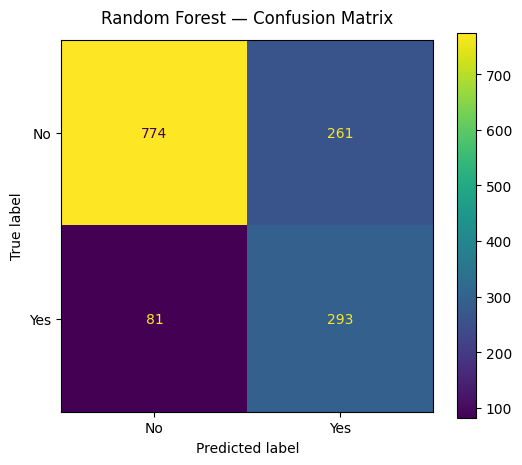

In [122]:
plot_confusion_matrix(
	best_rf_pipe,
	y_test,
	y_pred_rf,
	'Random Forest — Confusion Matrix',
)

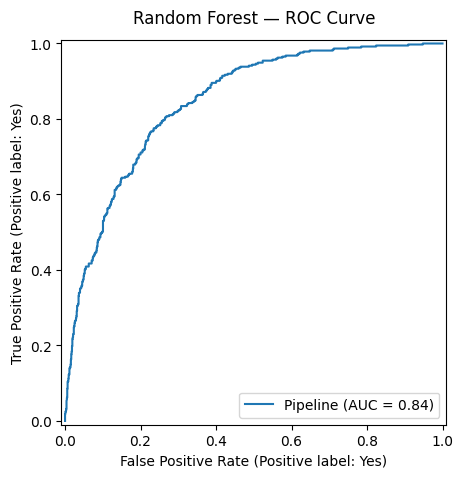

In [123]:
plot_roc_curve(
	best_rf_pipe,
	X_test,
	y_test,
	'Random Forest — ROC Curve',
)

In [124]:
base_rf_path = '../models/random_forest'

rf_artifacts = {
	'model_name': 'random_forest',
	'best_params': rf_study.best_params,
	'best_cv_score': rf_study.best_value,
	'test_metrics': rf_metrics,
	'cv_strategy': {
		'type': 'RepeatedStratifiedKFold',
		'n_splits': RSKF_N_SPLITS,
		'n_repeats': RSKF_N_REPEATS,
	},
	'random_state': RANDOM_STATE,
}

save_artifacts(base_rf_path, rf_artifacts, best_rf_pipe)

# XGBoost

# Model Comparison

This section will load the `*_artifacts.joblib` files from each model directory, aggregate the `test_metrics` dictionaries, and produce a side-by-side comparison of ROC-AUC, F1, Precision, and Recall.

The best-performing model will be selected for deployment in the Streamlit dashboard.